# 7. Do the Landsat sensors agree?

Four Landsat sensors cover the sites, and the change from Landsat 7 to Landsat 8 falls in 2013, inside the decade 2011–2020. If the sensors do not measure the same greenness at the same place, a trend that pools them has a step that is not in the land. This notebook pairs observations of two sensors at the same site a few days apart. It computes no trend.

docs/design.md set the rule for this comparison before any Landsat values were compared, and records how the rule was changed after the pairs and before any trend.

- **Reads** `sites.csv`, the files in `landsat/` and `modis_jul_aug_median.csv` from `data/processed/`. One cell asks Earth Engine for daily MODIS values.
- **Writes** `landsat_conversions.csv` to `data/processed/`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from mn_desertification import greenness, paths
from mn_desertification import satellite as sat
from mn_desertification.rules import FOOTPRINT_M, MIN_CLEAR

site_info = pd.read_csv(paths.PROCESSED_DIR / "sites.csv")

# The observations that count, as in the counts: one row a day, the 100 m circle, at least half of it clear
landsat = greenness.clearest_per_day(greenness.add_clear_share(greenness.read_landsat()))
landsat = landsat[(landsat["radius_m"] == FOOTPRINT_M) & (landsat["clear_share"] >= MIN_CLEAR)]
summer = greenness.in_season(landsat)   # 1 July to 31 August

# Two versions of the same observations
measured = greenness.with_indices(summer, to_landsat7=False)   # as each sensor measured it
converted = greenness.with_indices(summer, to_landsat7=True)   # Landsat 8 and 9 on the Landsat 7 scale
print("July-August observations that count:", len(summer))
measured.groupby("sensor")[["red", "nir", "ndvi"]].median().round(3)

July-August observations that count: 271317


,red,nir,ndvi
sensor,,,
landsat5,0.156,0.259,0.226
landsat7,0.154,0.258,0.226
landsat8,0.143,0.268,0.281
landsat9,0.146,0.273,0.278


NDVI is computed from the mean red and near-infrared reflectance of each circle. The observations are kept in two versions: as each sensor measured them, and with Landsat 8 and 9 put on the Landsat 7 scale by the published conversion of Roy et al. (2016).

Landsat 8 and 9 look greener in the table above, but the sensors cover different years. The pairs below compare like with like.

## Landsat 7 and Landsat 8

The rule set beforehand: observations of the two sensors at the same site, at most eight days apart in July or August, are paired. Each site's mean difference in NDVI is taken, then the mean over sites. The version that brings this mean closer to zero is the main one.

In [2]:
# Landsat 7 and Landsat 8 at the same site, at most eight days apart
pairs = greenness.sensor_pairs(measured, "landsat7", "landsat8")
print("Pairs:", len(pairs), "| sites:", pairs["gid"].nunique(), "| years:", pairs["year"].min(), "to", pairs["year"].max())
pairs["days_apart"].value_counts().sort_index().to_frame("pairs").T

Pairs: 56046 | sites: 1488 | years: 2013 to 2023


days_apart,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8
pairs,16222,336,456,314,669,427,689,9033,411,7908,377,718,340,424,621,283,16818


In [3]:
def pair_summary(observations, first_sensor, second_sensor, days=8):
    """The second sensor minus the first: each site's mean difference, then the mean over sites."""
    pairs = greenness.sensor_pairs(observations, first_sensor, second_sensor, days)
    row = {"pairs": len(pairs), "sites": pairs["gid"].nunique()}
    for name in ["red", "nir", "ndvi"]:
        by_site = (pairs[name + "_second"] - pairs[name + "_first"]).groupby(pairs["gid"]).mean()
        half_range = stats.t.ppf(0.975, len(by_site) - 1) * by_site.std() / np.sqrt(len(by_site))
        row[name] = by_site.mean()
        row[name + " 95% range"] = f"{by_site.mean() - half_range:+.4f} to {by_site.mean() + half_range:+.4f}"
    return row

choice = pd.DataFrame({"as measured": pair_summary(measured, "landsat7", "landsat8"),
                       "converted": pair_summary(converted, "landsat7", "landsat8")}).T
choice.round({"red": 4, "nir": 4, "ndvi": 4})

,pairs,sites,red,red 95% range,nir,nir 95% range,ndvi,ndvi 95% range
as measured,56046,1488,-0.006554,-0.0069 to -0.0062,0.005544,+0.0050 to +0.0060,0.029522,+0.0289 to +0.0302
converted,56046,1488,-0.003245,-0.0036 to -0.0029,0.005588,+0.0051 to +0.0061,0.018215,+0.0174 to +0.0191


- **As measured, Landsat 8 reads greener,** by 0.030 NDVI. Its red reflectance is lower by 0.007 and its near infrared higher by 0.006.
- **The published conversion leaves 0.018.** It is closer to zero, so by the rule it is the main version. But it removes only about 40% of the difference.
- The pairs are balanced, with about as many having Landsat 8 first as second, so growth or drying between the two days cancels out on average.

In [4]:
# Where on the scale of greenness do the sensors differ? Pairs are grouped by their own mean NDVI
def by_level(observations):
    pairs = greenness.sensor_pairs(observations, "landsat7", "landsat8")
    level = pd.cut((pairs["ndvi_first"] + pairs["ndvi_second"]) / 2, [-1, 0.1, 0.2, 0.3, 0.5, 1])
    return (pairs["ndvi_second"] - pairs["ndvi_first"]).groupby(level, observed=True).agg(["size", "mean"])

levels = pd.concat({"as measured": by_level(measured), "converted": by_level(converted)}, axis=1)
levels.round(4)

as measured         converted        
                   size    mean      size    mean
(-1.0, 0.1]        8187  0.0208      7612  0.0321
(0.1, 0.2]        15367  0.0247     16123  0.0265
(0.2, 0.3]         9733  0.0323      9985  0.0264
(0.3, 0.5]        14474  0.0364     14832  0.0172
(0.5, 1.0]         8285  0.0267      7494 -0.0143

             pairs sites      ndvi      ndvi 95% range
as measured  17352  1349  0.027183  +0.0262 to +0.0282
converted    17352  1349  0.015974  +0.0148 to +0.0171


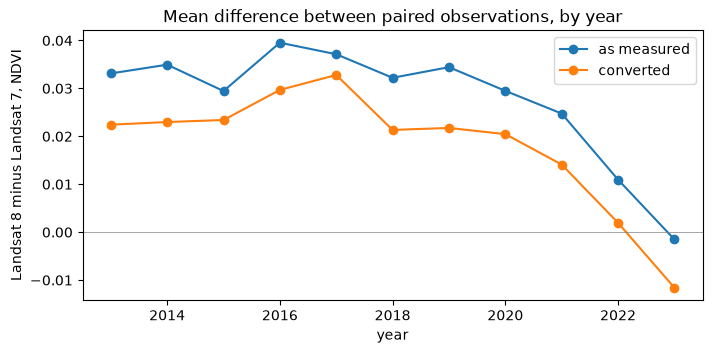

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
as measured,0.0331,0.0349,0.0295,0.0395,0.0371,0.0322,0.0344,0.0295,0.0247,0.0110,-0.0015
converted,0.0224,0.0230,0.0234,0.0297,0.0328,0.0213,0.0217,0.0205,0.0141,0.0019,-0.0116


In [5]:
# Two checks on the choice: pairs one day apart only, and the difference year by year
one_day = pd.DataFrame({"as measured": pair_summary(measured, "landsat7", "landsat8", days=1),
                        "converted": pair_summary(converted, "landsat7", "landsat8", days=1)}).T
print(one_day[["pairs", "sites", "ndvi", "ndvi 95% range"]].round({"ndvi": 4}).to_string())

yearly = {}
for name, observations in [("as measured", measured), ("converted", converted)]:
    pairs = greenness.sensor_pairs(observations, "landsat7", "landsat8")
    yearly[name] = (pairs["ndvi_second"] - pairs["ndvi_first"]).groupby(pairs["year"]).mean()
yearly = pd.DataFrame(yearly)

ax = yearly.plot(marker="o", figsize=(8, 3.5))
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_ylabel("Landsat 8 minus Landsat 7, NDVI")
ax.set_title("Mean difference between paired observations, by year")
plt.show()
yearly.round(4).T

- **The published conversion bends the scale.** It goes too far above an NDVI of 0.5 and leaves more than no conversion below 0.1.
- **Pairs one day apart give the same picture,** so the eight days between most pairs are not the cause.
- **The difference is steady from 2013 to 2020 and falls after.** The Earth Engine catalog notes that Landsat 7 has drifted to an earlier time of day since 2017. Landsat 7 after 2020 cannot be compared with its earlier years.

## The other sensors

In [6]:
# The other pairs of sensors
other_rows = {}
for first_sensor, second_sensor in [("landsat5", "landsat7"), ("landsat7", "landsat9"), ("landsat8", "landsat9")]:
    for name, observations in [("as measured", measured), ("converted", converted)]:
        row = pair_summary(observations, first_sensor, second_sensor)
        other_rows[(f"{second_sensor} minus {first_sensor}", name)] = {key: row[key] for key in ["pairs", "sites", "ndvi", "ndvi 95% range"]}
pd.DataFrame(other_rows).T.round({"ndvi": 4})

pairs sites      ndvi      ndvi 95% range
landsat7 minus landsat5 as measured  57538  1488   0.00746  +0.0069 to +0.0081
                        converted    57538  1488   0.00746  +0.0069 to +0.0081
landsat9 minus landsat7 as measured   8259  1463  0.000374  -0.0008 to +0.0016
                        converted     8259  1463 -0.012286  -0.0140 to -0.0106
landsat9 minus landsat8 as measured  22557  1487 -0.001252  -0.0019 to -0.0006
                        converted    22557  1487 -0.001387  -0.0020 to -0.0008

Landsat 7 reads slightly greener than Landsat 5, and Landsat 9 agrees with Landsat 8. The pairs of Landsat 9 with Landsat 7 are from 2022 and 2023 only, when Landsat 7 had drifted.

## Two smaller checks

The first compares the NDVI of a circle's mean reflectances, which the rule uses, with the mean of its pixels' own NDVI. The second concerns MODIS: notebook 5 took each pixel's median over the season first and the mean within the circle second, and the rule is now the other way round. Daily MODIS values of the circles are extracted for three years and summarised the new way.

In [7]:
# The index of the mean reflectances against the mean of the pixels' own index
gap = measured["ndvi"] - measured["ndvi_pixels"]
print("NDVI of the means minus mean of the pixels' NDVI: mean", round(gap.mean(), 4), "| mean absolute", round(gap.abs().mean(), 4),
      "| correlation", round(measured["ndvi"].corr(measured["ndvi_pixels"]), 4))
print("Share of observations where the two differ by more than 0.01:", round((gap.abs() > 0.01).mean(), 3))

NDVI of the means minus mean of the pixels' NDVI: mean -0.0001 | mean absolute 0.0005 | correlation 0.9999
Share of observations where the two differ by more than 0.01: 0.004


In [8]:
# MODIS: does it matter whether the median over the season or the mean within the circle comes first?
sat.connect()
modis_pixels = sat.modis_grid()
footprints = sat.site_footprints(site_info)
pixel_first = pd.read_csv(paths.PROCESSED_DIR / "modis_jul_aug_median.csv")

order_rows = []
for year in [2002, 2012, 2022]:
    days = pd.concat([sat.daily_values_at_sites(sat.modis_nbar(f"{year}-{month:02d}-01", f"{year}-{month + 1:02d}-01"),
                                                footprints, modis_pixels) for month in [7, 8]])
    days["ndvi"] = (days["nir"] - days["red"]) / (days["nir"] + days["red"])
    circle_first = days.groupby("gid")["ndvi"].median()
    earlier = pixel_first[pixel_first["year"] == year].set_index("gid")["ndvi"]
    gap = circle_first - earlier
    order_rows.append({"year": year, "sites": int(gap.notna().sum()), "correlation": circle_first.corr(earlier),
                       "mean absolute difference": gap.abs().mean(), "largest": gap.abs().max()})
pd.DataFrame(order_rows).round(4)

,year,sites,correlation,mean absolute difference,largest
0,2002,1488,1.0,0.0006,0.0185
1,2012,1488,1.0,0.0008,0.0141
2,2022,1488,1.0,0.0007,0.0152


Neither matters. The two ways of getting a circle's NDVI differ by 0.0005 on average, and the two orders for MODIS by 0.0006 to 0.0008.

## A conversion fitted to these sites

Neither version brings Landsat 7 and Landsat 8 together. On 11 October 2026, after the pairs above and before any trend, the rule was changed: the main version is a conversion fitted to these sites' own pairs, the published conversion and no conversion are the checks, and Landsat 7 after 2020 is left out.

The fit is one line per band, the reduced major axis: its slope is the ratio of the two sensors' standard deviations, and it passes through their means. Unlike least squares it allows for error in both sensors. A fit looks good on the data it was fitted to, so it is fitted on the sites with an even number and tested on the others, with the pairs of 2013–2020.

In [9]:
# A conversion fitted to these sites, tested on sites it has not seen
decade_pairs = greenness.sensor_pairs(measured, "landsat7", "landsat8")
decade_pairs = decade_pairs[decade_pairs["year"] <= 2020]                           # before Landsat 7's drift shows
half_fit = greenness.fit_conversion(decade_pairs[decade_pairs["gid"] % 2 == 0])    # the sites with an even number
print("Fitted on half the sites:", {band: (round(a, 4), round(b, 4)) for band, (a, b) in half_fit.items()})

held_out = summer[(summer["gid"] % 2 == 1) & (summer["year"] <= 2020)]             # the other sites
versions = {"as measured": greenness.with_indices(held_out, to_landsat7=False),
            "published conversion": greenness.with_indices(held_out),
            "fitted on the other sites": greenness.with_indices(held_out, conversions={"landsat8": half_fit})}
test = pd.DataFrame({name: pair_summary(table, "landsat7", "landsat8") for name, table in versions.items()}).T
test[["pairs", "sites", "ndvi", "ndvi 95% range"]].round({"ndvi": 4})

Fitted on half the sites: {'red': (0.0053, 1.0223), 'nir': (0.0041, 0.967)}


,pairs,sites,ndvi,ndvi 95% range
as measured,21521,744,0.035047,+0.0340 to +0.0361
published conversion,21521,744,0.024507,+0.0233 to +0.0257
fitted on the other sites,21521,744,0.000544,-0.0005 to +0.0015


In [10]:
# The same test along the scale of greenness
def difference_by_level(table):
    pairs = greenness.sensor_pairs(table, "landsat7", "landsat8")
    level = pd.cut((pairs["ndvi_first"] + pairs["ndvi_second"]) / 2, [-1, 0.1, 0.2, 0.3, 0.5, 1])
    return (pairs["ndvi_second"] - pairs["ndvi_first"]).groupby(level, observed=True).mean()

pd.DataFrame({name: difference_by_level(table) for name, table in versions.items()}).round(4)

,as measured,published conversion,fitted on the other sites
"(-1.0, 0.1]",0.0231,0.0337,-0.0080
"(0.1, 0.2]",0.0286,0.0307,-0.0025
"(0.2, 0.3]",0.0376,0.0316,0.0044
"(0.3, 0.5]",0.0420,0.0232,0.0053
"(0.5, 1.0]",0.0352,-0.0057,-0.0017


On sites the fit has not seen, the difference is 0.0005 NDVI, with a range that includes zero, and it stays within 0.008 of zero along the whole scale of greenness.

For the trends the lines are fitted on every site. Landsat 5 gets its own lines from its pairs with Landsat 7, 1999–2011, and Landsat 9 takes the lines of Landsat 8.

In [11]:
# The lines for use, fitted on every site, and what they leave between each pair of sensors
early_pairs = greenness.sensor_pairs(measured, "landsat5", "landsat7")              # 1999 to 2011
conversions = {"landsat5": greenness.fit_conversion(early_pairs, onto="second"),     # Landsat 7 is the second of each pair
               "landsat8": greenness.fit_conversion(decade_pairs)}
conversions["landsat9"] = conversions["landsat8"]
lines = pd.DataFrame([{"sensor": sensor, "band": band, "intercept": intercept, "slope": slope}
                      for sensor, bands in conversions.items() for band, (intercept, slope) in bands.items()])
lines.to_csv(paths.PROCESSED_DIR / "landsat_conversions.csv", index=False)
print(lines.round(4).to_string(index=False))

drifted = (summer["sensor"] == "landsat7") & (summer["year"] > 2020)                # left out by the rule
fitted = greenness.with_indices(summer[~drifted], conversions=conversions)
after = {f"{second} minus {first}": pair_summary(fitted, first, second)
         for first, second in [("landsat5", "landsat7"), ("landsat7", "landsat8"), ("landsat8", "landsat9")]}
pd.DataFrame(after).T[["pairs", "sites", "red", "nir", "ndvi", "ndvi 95% range"]].round({"red": 4, "nir": 4, "ndvi": 4})

  sensor band  intercept  slope
landsat5  red    -0.0067 1.0187
landsat5  nir    -0.0064 1.0133
landsat8  red     0.0047 1.0262
landsat8  nir     0.0004 0.9810
landsat9  red     0.0047 1.0262
landsat9  nir     0.0004 0.9810


,pairs,sites,red,nir,ndvi,ndvi 95% range
landsat7 minus landsat5,57538,1488,-0.000146,0.000102,0.00042,-0.0000 to +0.0009
landsat8 minus landsat7,42849,1488,-0.000556,-0.000382,0.000585,-0.0001 to +0.0013
landsat9 minus landsat8,22557,1487,0.001579,0.002607,-0.001131,-0.0017 to -0.0005


After the conversion every pair of sensors agrees to about 0.001 NDVI. These last numbers come from the same pairs the lines were fitted to, so they show that the fit did what it should. The test on unseen sites above is the measure of how good it is.

## In short

- **Landsat 8 reads greener than Landsat 7 at these sites,** by 0.030 NDVI as measured.
- **The published conversion leaves 0.018** and bends the scale.
- **A conversion fitted to these sites leaves 0.0005 on sites it had not seen.** It is the main version for the trends.
- **Landsat 7 after 2020 is left out,** because its difference from Landsat 8 falls to zero by 2023.
- **The index of mean reflectances, and the order of median and mean for MODIS, make no difference.**